In [29]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


In [30]:
load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [31]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)


In [32]:
# create state 

class BlogState(TypedDict):

    title : str
    content: str
    outline: str
    evaluate: int

In [33]:
def create_outline(state: BlogState) -> BlogState:
    
    # fetch title
    title = state['title']

    # form a prompt
    prompt = f'Generate a detailed outline for a blog on the topic \n {title}'

    # ask that question to llm
    outline = model.invoke(prompt).content

    # update the outline in the state
    state['outline'] = outline

    return state



In [34]:
def create_blog(state: BlogState) -> BlogState:
    
    # fetch title and outline
    title = state['title']
    outline = state['outline']


    # form a prompt
    prompt = f'write a detailed blog on the title - \n {title} using the following outline \n {outline}'

    # ask that question to llm
    content = model.invoke(prompt).content

    # update the content in the state
    state['content'] = content

    return state

In [35]:
def create_evaluation(state: BlogState) -> BlogState:
    
    # fetch outline
    outline = state['outline']


    # form a prompt
    prompt = f'Based on the following outline - \n {outline} , rate the blog on a scale of 1-10'

    # ask that question to llm
    evaluate = model.invoke(prompt).content

    # update the content in the state
    state['evaluate'] = evaluate

    return state

In [36]:
# create our graph

graph = StateGraph(BlogState)

# add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('create_evaluation',create_evaluation)


# add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog', 'create_evaluation')
graph.add_edge('create_evaluation', END)



# compile the graph
workflow = graph.compile()

In [ ]:
# execute the graph
initial_state = {'title':'Rise of AI in pakistan?'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in pakistan?', 'content': '## Pakistan\'s AI Frontier: Opportunities, Challenges, and the Road Ahead\n\nThe world is in the midst of a technological renaissance, a revolution powered by Artificial Intelligence. From self-driving cars to personalized medicine, AI is rapidly reshaping industries, economies, and societies at an unprecedented pace. While global superpowers and tech giants grapple with the profound implications of this paradigm shift, a crucial question arises: **How is an emerging economy like Pakistan positioning itself in this new digital era?**\n\nPakistan, a nation characterized by its vibrant youth, burgeoning digital literacy, and an increasing strategic focus on technology, finds itself at a pivotal juncture. AI is no longer a distant dream but a burgeoning reality here, poised to drive significant transformation despite facing unique challenges. This blog post will delve into the current AI landscape in Pakistan, explore the factors driving it

In [ ]:
print(final_state['content'])
print(final_state['outline'])
print(final_state['evaluate'])


This outline is **10/10**.

Here's a breakdown of why:

**Strengths:**

1.  **Exceptional Detail and Comprehensiveness:** The outline goes far beyond just topic headings. It provides sub-points, specific examples relevant to Pakistan (e.g., "Digital Pakistan," NCAI, specific universities, incubators), and concrete ideas for content within each section. This level of detail makes it incredibly easy for a writer to produce a well-structured and informative blog post.
2.  **Logical Flow and Structure:** The progression from introduction to current landscape, driving factors, opportunities, challenges, key players, future outlook, and conclusion is perfectly logical and creates a cohesive narrative.
3.  **Balanced Perspective:** It effectively covers both the immense opportunities and the significant challenges, providing a realistic and nuanced view of AI's rise in Pakistan.
4.  **Strong Introduction and Conclusion:**
    *   The introduction has an excellent hook, sets the global context

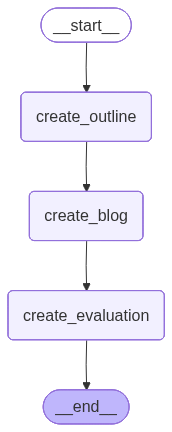

In [39]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())